# Bus Data
### Projekt PAD
### Viktória Kovácsová

# Úvod

V tejto analýze sme použili vlastné pozorovania pasažierov na linke z **Nových Zámkov** do **Nitry**. Dáta sme zbierali v stredu ráno 19.11., počas spoja odchádzajúceho o 7:55. Dataset poskytuje informácie o jednotlivých cestujúcich v autobuse, mapuje demografické údaje, cestovné parametre a správanie cestujúcich.

Najdôležitejšie premenné, ktoré v analýze použijeme, sú:
- `has_discount_ticket` typ lístka pasažiera (dichotomická: Yes = zľavnený / No = celý)
- `origin_stop` nástupná zastávka (nominálna: Nové Zámky, Šurany, Komjatice, Veľký Kýr, Branč, Ivanka pri Nitre, Nitra)
- `destination` výstupová zastávka (nominálna: Šurany, Komjatice, Veľký Kýr, Branč, Ivanka pri Nitre, Nitra)
- `age_group` veková kategória (ordinálna textová: Child, Teen, Young_adult, Adult, Senior)
- `device_engagement` úroveň používania telefónu (ordinálna číselná 1 = počas celej jazdy nemá mobil v ruke → 5 = neustále používa mobil)
- `minutes_on_bus` čas strávený v autobuse v minútach (intervalová)
- `travelled_distance_km` prejdená vzdialenosť v km (pomerná, výpočet)
- `bag_weight_kg` približná hmotnosť batožiny v kg (pomerná)

Prvým krokom je importovať potrebné knižnice na analýzu dát, ako aj špecifické štatistické funkcie pre overovanie normality, rovnosti rozptylov, testovanie stredných hodnôt a koreláciu.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu, spearmanr, kruskal, chi2_contingency

Následne naimportujeme dataset.

In [3]:
df = pd.read_excel('NOVY_bus_data.xlsx')

Aby sme mali prehľad, čo dataset obsahuje, vykreslíme časť dataframu.

In [4]:
df.head()

,Záznam,has_discount_ticket,origin_stop,destination,age_group,device_engagement,minutes_on_bus,travelled_distance_km,bag_weight_kg
0,1,Yes,Nové Zámky,Nitra,Young_adult,4,57,39,4.50
1,2,Yes,Nové Zámky,Nitra,Teen,5,57,39,3.80
2,3,Yes,Nové Zámky,Nitra,Young_adult,2,57,39,4.75
3,4,No,Nové Zámky,Nitra,Adult,4,57,39,0.50
4,5,Yes,Nové Zámky,Nitra,Senior,1,57,39,0.75


## Exploračná analýza - prehľad

V tejto časti preskúmame základné charakteristiky datasetu a rozdelenie jednotlivých premenných, aby sme vytvorili vizuálne závery a formulovali testovateľné hypotézy

Začíname súhrnnou štatistikou pre kľúčové metrické premenné, aby sme pochopili ich centrálnu tendenciu a variabilitu.

In [5]:
print(df[['minutes_on_bus', 'travelled_distance_km', 'bag_weight_kg', 'device_engagement']].describe().round(2))

       minutes_on_bus  travelled_distance_km  bag_weight_kg  device_engagement
count           32.00                  32.00          32.00              32.00
mean            36.03                  19.81           1.57               2.38
std             15.52                  11.40           1.45               1.50
min              6.00                   3.00           0.00               1.00
25%             29.00                  13.00           0.50               1.00
50%             37.00                  18.00           0.92               2.00
75%             42.00                  20.00           2.86               4.00
max             57.00                  39.00           4.75               5.00


Záver: Vysoká smerodajná odchýlka pre minutes_on_bus (15.52) a travelled_distance_km (11.40) naznačuje veľké rozdiely v dĺžke ciest medzi cestujúcimi (6 až 57 minút). Rozptyl hodnôt je značný, čo znamená, že niektorí cestujúci cestujú výrazne kratšie alebo dlhšie ako priemer.

Aby sme potvrdili šikmosť a prítomnosť odľahlých hodnôt, preskúmame rozdelenie `minutes_on_bus` pomocou histogramu a boxplotu.

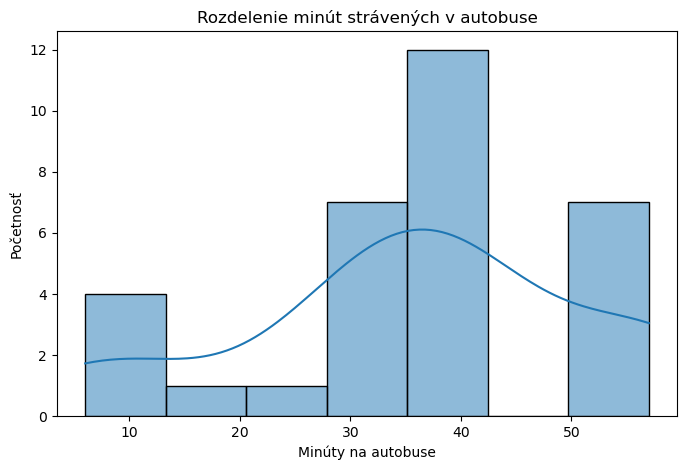

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df['minutes_on_bus'], kde=True)
plt.title('Rozdelenie minút strávených v autobuse')
plt.xlabel('Minúty na autobuse')
plt.ylabel('Početnosť')
plt.show()

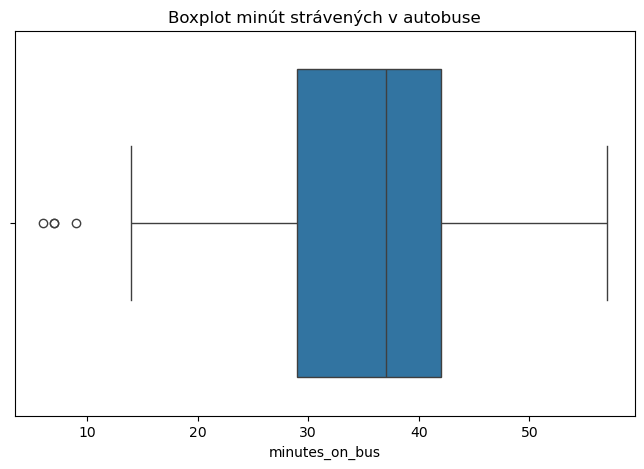

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['minutes_on_bus']) 
plt.title('Boxplot minút strávených v autobuse') 
plt.show()

Záver: Záver: Histogram a boxplot ukazujú, že čas strávený v autobuse sa pohybuje od 6 do 57 minút. Priemerný čas je približne 36 minút, pričom niektorí cestujúci cestujú výrazne kratšie alebo dlhšie ako priemer.

V Inferenčnej Analýze (Test 1) formálne otestujeme, či existuje rozdiel v dĺžke cesty medzi pasažiermi so zľavou a bez nej.

Preskúmame zastúpenie cestujúcich podľa vekovej kategórie (`age_group`) a ich prepojenie s držaním zľavy (`has_discount_ticket`).

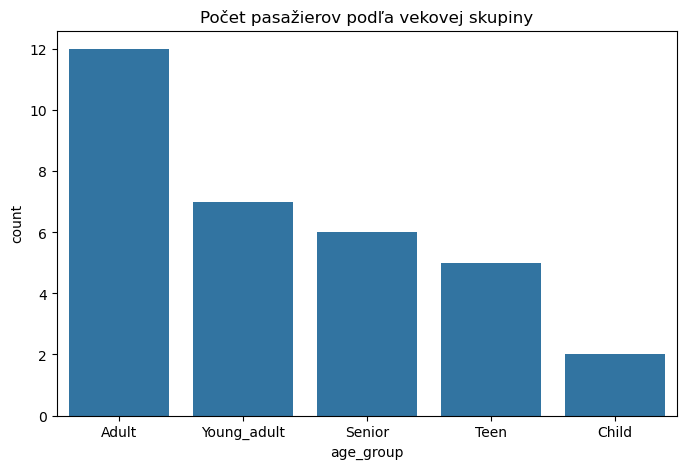

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="age_group", order=df["age_group"].value_counts().index)
plt.title("Počet pasažierov podľa vekovej skupiny")
plt.show()

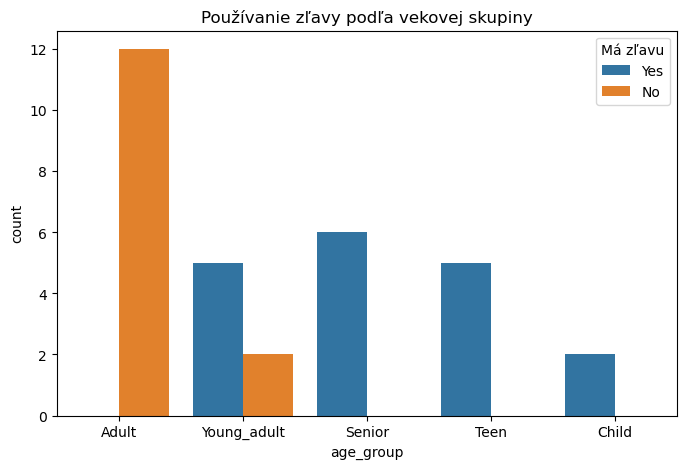

In [54]:
age_counts = df['age_group'].value_counts().index

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="age_group", hue="has_discount_ticket", order=age_counts)
plt.title("Používanie zľavy podľa vekovej skupiny")
plt.legend(title='Má zľavu', loc='upper right')
plt.show()

Záver: Skupina Adult je najväčšia (12 osôb). Z vizualizácie zliav vyplýva, že zľavy sú logicky dominantné u kategórií Teen, Child a Senior. U skupiny Young_adult vidíme zmes (5 zo 7 má zľavu), čo potvrdzuje prítomnosť študentov. (od roku 18 do 26 zľavnený lístok môžu dostať študenti)

Na základe týchto zistení transformujeme dáta a vytvoríme binárnu premennú `is_student` na filtrovanie a testovanie špecifických hypotéz o správaní študentov (napr. vzťah k batožine a miesto nástupu).

In [4]:
df['is_student'] = np.where(
(df['age_group'] == 'Child')  |
(df['age_group'] == 'Teen') |
((df['age_group'] == 'Young_adult') & (df['has_discount_ticket'] == 'Yes')),
True,
False
)

print("\nRozdelenie novej premennej is_student:")
print(df['is_student'].value_counts())


Rozdelenie novej premennej is_student:
is_student
False    20
True     12
Name: count, dtype: int64


S novou premennou preskúmame vzťah študenta k fyzickej záťaži (`bag_weight_kg`) a geografická koncentrácia študentov (`origin_stop`).
Boxplot nám umožní vizuálne porovnať mediány a variabilitu hmotnosti batožiny medzi študentmi a neštudentmi, čím získame vizuálny dôkaz pre nadchádzajúci inferenčný test.

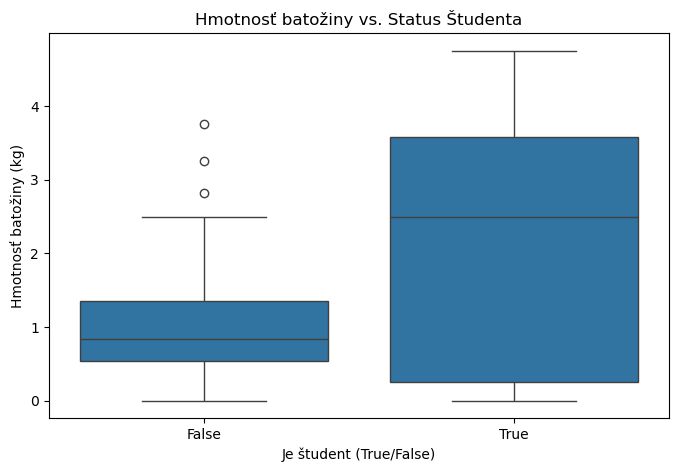

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='is_student', y='bag_weight_kg', data=df)
plt.title('Hmotnosť batožiny vs. Status Študenta')
plt.xlabel('Je študent (True/False)')
plt.ylabel('Hmotnosť batožiny (kg)')
plt.show()

Z boxplotu vidíme, že študenti nesú tendenciu mať ťažšiu batožinu než neštudenti. Aby sme overili, či je tento rozdiel štatisticky významný, vykonáme Mann-Whitney U test, ktorý porovnáva mediány medzi skupinami.

Čo ďalej: Skontrolujeme, či cestovná vzdialenosť súvisí s hmotnosťou batožiny (Test 2).

Preskúmanie nehomogenity cestujúcich na rôznych zastávkach. Ak sú vekové skupiny nehomogénne rozdelené, naznačuje to, že existuje závislosť medzi nástupnou zastávkou a demografickou štruktúrou.

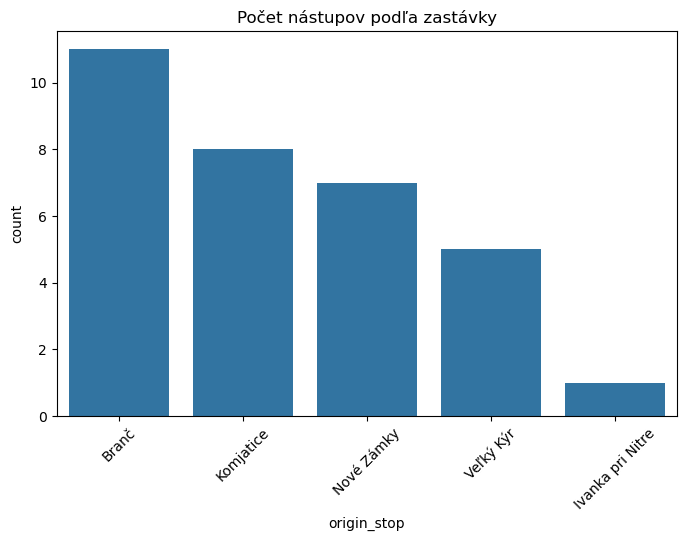

In [27]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="origin_stop",
              order=df["origin_stop"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Počet nástupov podľa zastávky")
plt.show()

In [9]:
pivot = pd.pivot_table(
    df,index="origin_stop", columns="age_group", values="minutes_on_bus", aggfunc="count", margins=True).fillna(0)
pivot

age_group,Adult,Child,Senior,Teen,Young_adult,All
origin_stop,,,,,,
Branč,6.0,0.0,5.0,0.0,0.0,11
Ivanka pri Nitre,1.0,0.0,0.0,0.0,0.0,1
Komjatice,2.0,2.0,0.0,3.0,1.0,8
Nové Zámky,2.0,0.0,1.0,1.0,3.0,7
Veľký Kýr,1.0,0.0,0.0,1.0,3.0,5
All,12.0,2.0,6.0,5.0,7.0,32


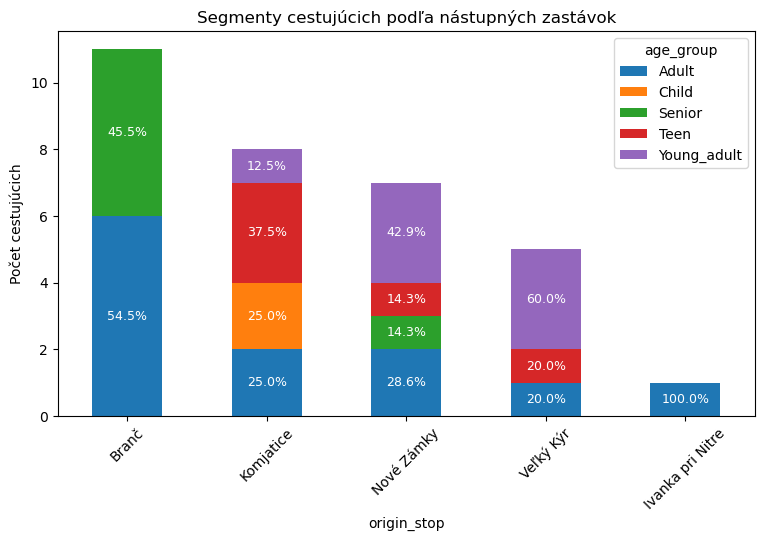

In [17]:
pivot_clean = pivot.drop(index="All", columns="All")
pivot_sorted = pivot_clean.loc[pivot_clean.sum(axis=1).sort_values(ascending=False).index]

ax = pivot_sorted.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Segmenty cestujúcich podľa nástupných zastávok")
plt.xticks(rotation=45)
plt.ylabel("Počet cestujúcich")

# Add percentages inside each bar
for j, row in enumerate(pivot_sorted.itertuples(index=False)):
    total = sum(row)
    cum_height = 0
    for i, val in enumerate(row):
        if val > 0:
            ax.text(x=j, y=cum_height + val/2, s=f'{val/total*100:.1f}%', 
                    ha='center', va='center', color='white', fontsize=9)
        cum_height += val

plt.show()

Zastávka Branč je najfrekventovanejšia zastávka (11 cestujúcich) a z vizualizácie je viditeľné, že je dominantná pre segmenty Adult a Senior. Zastávky Komjatice a Nové Zámky sú naopak kľúčové pre mladú populáciu, s vysokým zastúpením Teen a Young_adult. Tieto zastávky sú teda demograficky nehomogénne.

Pri pohľade na status študenta vidíme:

In [5]:
pivot_student = pd.pivot_table(
    df,index="origin_stop", columns="is_student", values="minutes_on_bus", aggfunc="count", margins=True).fillna(0)
pivot_student

is_student,False,True,All
origin_stop,,,
Branč,11.0,0.0,11
Ivanka pri Nitre,1.0,0.0,1
Komjatice,3.0,5.0,8
Nové Zámky,3.0,4.0,7
Veľký Kýr,2.0,3.0,5
All,20.0,12.0,32


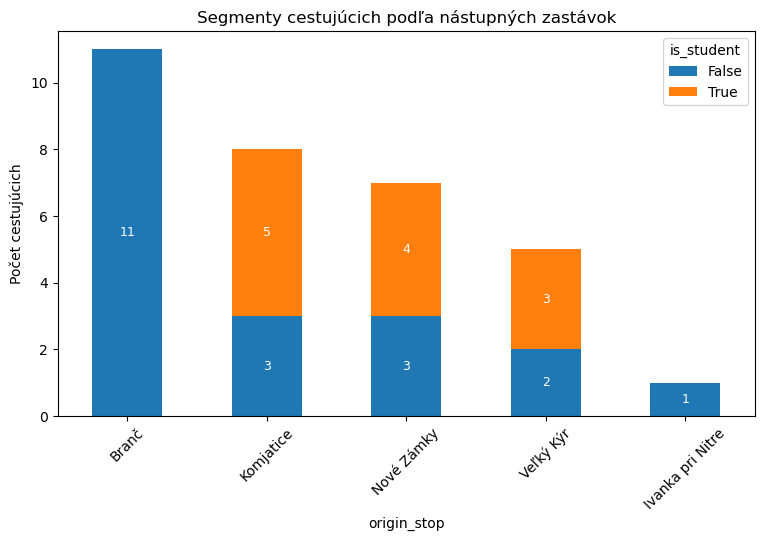

In [18]:
pivot_clean_student = pivot_student.drop(index="All", columns="All")
pivot_sorted_student = pivot_clean_student.loc[pivot_clean_student.sum(axis=1).sort_values(ascending=False).index]

ax = pivot_sorted_student.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Segmenty cestujúcich podľa nástupných zastávok")
plt.xticks(rotation=45)
plt.ylabel("Počet cestujúcich")

for j, row in enumerate(pivot_sorted_student.itertuples(index=False)):
    cum_height = 0
    for val in row:
        if val > 0:
            ax.text(x=j, y=cum_height + val/2, s=int(val), ha='center', va='center', color='white', fontsize=9)
        cum_height += val

plt.show()

Zastávky Branč a Ivanka pri Nitre sú typicky navštevované neštudentami; Komjatice, Nové Zámky a Veľký Kýr majú vyšší podiel študentov.

Záver: Demografická štruktúra zastávok je rôznorodá a nie je rovnomerne rozdelená podľa statusu študenta. Niektoré zastávky sú viac orientované na mladú populáciu (študenti), iné na dospelých a seniorov.

V budúcej analýze overíme štatistickú závislosť medzi `origin_stop` a `is_student`.

Tieto zistenia o demografickej nehomogenite zastávok naznačujú, že vek a študentský status cestujúcich sú kľúčovými faktormi pri plánovaní trás a služieb. Aby sme lepšie pochopili správanie rôznych vekových skupín počas jazdy, vizuálne overíme vzťah medzi vekom a digitálnym zapojením (`device_engagement`).

In [20]:
print("Kontingenčná tabuľka: Priemerný device_engagement podľa age_group")
pivot_engagement = pd.pivot_table(df, 
               index="age_group", 
               values="device_engagement", 
               aggfunc='mean').sort_values(by='device_engagement', ascending=False)
print(pivot_engagement.map(lambda x: f"{x:.2f}"))

Kontingenčná tabuľka: Priemerný device_engagement podľa age_group
            device_engagement
age_group                    
Teen                     4.20
Young_adult              3.29
Adult                    1.92
Child                    1.50
Senior                   1.00


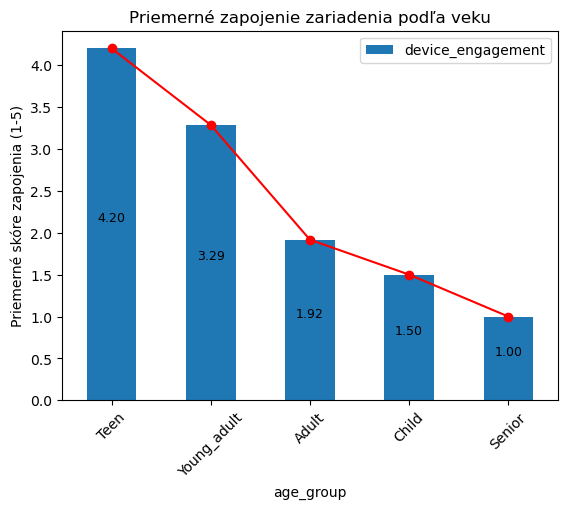

In [24]:
ax = pivot_engagement.plot.bar()
pivot_engagement['device_engagement'].plot.line(marker='o', color='red', ax=ax)
plt.title('Priemerné zapojenie zariadenia podľa veku')
plt.ylabel('Priemerné skóre zapojenia (1-5)')
plt.xticks(rotation=45)
for i, val in enumerate(pivot_engagement['device_engagement']):
    ax.text(i, val/2, f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.show()

Záver: Vek je kľúčovým faktorom pre digitálne správanie sa počas cesty
- Engagement dosahuje vrchol u Teen (4.20), potom klesá.
- Child → Teen (+2.70): teenageri začínajú intenzívne používať mobily
- Young_adult → Adult (-1.37): prechod do pracovného života znižuje čas na mobily
- Senior (1.00): dôchodcovia takmer nepoužívajú mobily počas cesty

Čo ďalej: Overiť štatistickú významnosť korelácie medzi vekom a `device_engagement` pomocou Spearmanovho rho.

# **Analýza 1**
## **Inferenčná analýza - testy o stredných hodnotách**

Cieľom nasledujúcej analýzy je zistiť, ktoré faktory odlišujú cestujúcich a aké premeny medzi sebou štatisticky súvisia.

Budeme overovať tieto okruhy:
- Má zľava vplyv na dĺžku cesty?
`(minutes_on_bus × has_discount_ticket)`
- Nosia študenti inú hmotnosť batožiny než neštudenti?
`(bag_weight_kg × is_student)`

**Test 1: `minutes_on_bus` vs. `has_discount_ticket`**

Overujeme, či rozdielne cestovné kategórie (definované zľavou) vedú k signifikantne odlišným priemerným časom stráveným v autobuse.
Cestujúci so zľavou (študenti, seniori) často využívajú autobus ako hlavný dopravný prostriedok a môžu cestovať na dlhšie trasy, zatiaľ čo cestujúci bez zľavy väčšinou absolvujú kratšie, príležitostné cesty.

H0 (Nulová hypotéza): Nie je štatisticky významný rozdiel medzi priemerným časom stráveným v autobuse (minutes_on_bus) pre cestujúcich so zľavou a cestujúcich bez zľavy.

Parametrické testy vyžadujú normálne rozdelenie dát. Pre použitie parametrického Dvojvýberového T-testu musíme overiť, či sú dáta normálne rozdelené (Shapiro-Wilk) a či majú homogénne rozptyly (Levene's test)

In [34]:
minutes_disc = df[df['has_discount_ticket'] == 'Yes']['minutes_on_bus']
minutes_no_disc = df[df['has_discount_ticket'] == 'No']['minutes_on_bus']

print("--- Kontrola Normality ---")
print(f"Shapiro-Wilk p pre Zľava=Áno: {shapiro(minutes_disc).pvalue}")
print(f"Shapiro-Wilk p pre Zľava=Nie: {shapiro(minutes_no_disc).pvalue}")

--- Kontrola Normality ---
Shapiro-Wilk p pre Zľava=Áno: 0.07025675782226651
Shapiro-Wilk p pre Zľava=Nie: 0.21777204057920418


Obe p-hodnoty pre Shapiro-Wilk sú >0.05 (0.0703 a 0.2178), preto nezamietame H0 o normalite. Levene's test (H0: Rozptyly sú rovnaké) určí, ktorú verziu T-testu použijeme.

In [35]:
print(f"Levene's p-hodnota: {levene(minutes_disc, minutes_no_disc).pvalue}")

Levene's p-hodnota: 0.36727727593041604


P-hodnota pre Levene's test (0.3673) je tiež > 0.05, čo znamená, že rozptyly sú homogénne (rovnaké), použijeme parametrický Dvojvýberový T-test so združeným rozptylom (equal_var=True).

In [36]:
t_stat, p_value = ttest_ind(minutes_disc, minutes_no_disc, equal_var=True)
print(f"T-Test p-hodnota: {p_value}")

T-Test p-hodnota: 0.09193236964216682


Záver: Vypočítaná p−hodnota > 0.05. Preto nezamietame nulovú hypotézu (H0).
Štatisticky významný rozdiel medzi priemerným časom stráveným v autobuse pre cestujúcich so zľavou a bez zľavy nebol zistený.

**Test 2: `bag_weight_kg` vs. `is_student`**

Testovali sme, či študenti (definovaní pomocou premennej is_student) nosia štatisticky významne odlišnú hmotnosť batožiny ako neštudenti.

H0: Nie je štatisticky významný rozdiel v mediáne `bag_weight_kg` medzi skupinou `is_student` (True) a `is_student` (False).

In [37]:
bag_student = df[df['is_student'] == True]['bag_weight_kg']
bag_non_student = df[df['is_student'] == False]['bag_weight_kg']

print("\n--- Kontrola Normality pre Bag Weight vs. Is Student ---")
print(f"Shapiro-Wilk p pre Študent=Áno: {shapiro(bag_student).pvalue}")
print(f"Shapiro-Wilk p pre Študent=Nie: {shapiro(bag_non_student).pvalue}")


--- Kontrola Normality pre Bag Weight vs. Is Student ---
Shapiro-Wilk p pre Študent=Áno: 0.0561771261077463
Shapiro-Wilk p pre Študent=Nie: 0.003767928810745321


Normalita pre skupinu neštudentov bola zamietnutá (p=0.0038 < 0.05)

Keďže pre parametrický t-test musia byť obe skupiny normálne rozdelené, podmienka nie je splnená. Preto používame neparametrickú alternatívu, Mann-Whitney U test, ktorý porovnáva mediány medzi dvoma nezávislými skupinami.

In [38]:
u_stat, p_value = mannwhitneyu(bag_student, bag_non_student, alternative='two-sided')
print(f"Mann-Whitney U p-hodnota: {p_value}")

Mann-Whitney U p-hodnota: 0.43513640642211593


Záver: Hodnota p je výrazne vyššia než hladina významnosti 0.05, preto nulovú hypotézu nezamietame.
To znamená, že nebol zistený žiadny štatisticky významný rozdiel v mediáne hmotnosti batožiny medzi študentmi a neštudentmi.

Napriek tomu, že v exploračnej analýze bol medzi skupinami vizuálne pozorovateľný rozdiel (v boxplote), štatistický test potvrdzuje, že tento rozdiel nie je dostatočne veľký na to, aby bol považovaný za významný.

# **Analýza 2**
## **Inferenčná analýza - Korelačná analýza**

Dataset o cestujúcich uvádza viacero dôležitých premenných, ktoré môžu ovplyvňovať správanie pasažierov počas jazdy autobusom. Zameriame sa najmä na tri oblasti:
- Vzťah vekovej skupiny a mierou používania mobilných zariadení (device_engagement)
- Vzťah prejdenej vzdialenosti a hmotnosti batožiny
- Vzťah medzi nástupnou zastávkou a tým, či je cestujúci študent

Cieľom je zistiť, ktoré faktory majú štatisticky významný vplyv a zistiť, kde existujú výrazné rozdiely medzi skupinami..
Výsledky nám môžu pomôcť pochopiť správanie cestujúcich, segmentáciu publika, aj možné smerovanie odporúčaní pre dopravcu.

**Test 3: device_engagement vs. age_group**

Dataset obsahuje informáciu o tom, ako intenzívne cestujúci používa svoje zariadenie počas jazdy (škála 1–5).
Zároveň máme rozdelenie na päť vekových skupín: Child, Teen, Young adult, Adult, Senior.

Cieľom je zistiť či existuje vzťah medzi vekom cestujúceho a mierou používania mobilného zariadenia počas jazdy.

H0: Nie je štatisticky významná závislosť medzi vekovou skupinou a mierou používania mobilného zariadenia počas jazdy.

Najprv konvertujeme vekové kategórie na ordinálne hodnoty (1 = najmladší → 5 = najstarší), aby sme mohli kvantitatívne vyhodnotiť poradie vekových skupín a použiť Spearmanov korelačný test.

In [39]:
age_map = {
    "Child": 1,
    "Teen": 2,
    "Young_adult": 3,
    "Adult": 4,
    "Senior": 5
}

df["age_group_num"] = df["age_group"].map(age_map)

Keďže obe premenné sú ordinálne, používame Spearmanovu koreláciu, ktorá nevyžaduje normalitu ani rovnaké rozostupy medzi kategóriami.

In [51]:
corr, p = spearmanr(df["age_group_num"], df["device_engagement"])

print("Spearman rho:", corr)
print("p-hodnota:", p)

Spearman rho: -0.619504358103859
p-hodnota: 0.0001563196139892391


Spearmanova korelácia medzi `age_group` a `device_engagement` je negatívna a štatisticky významná.
H0 zamietáme (p < 0.05).

Vyšší vek je spojený s nižším používaním mobilného zariadenia, avšak tento vzťah nie je lineárny.
Najvyšší device engagement vykazujú Teen a Young adult, zatiaľ čo Child majú ešte relatívne nízke hodnoty a Seniori úplne najnižšie.

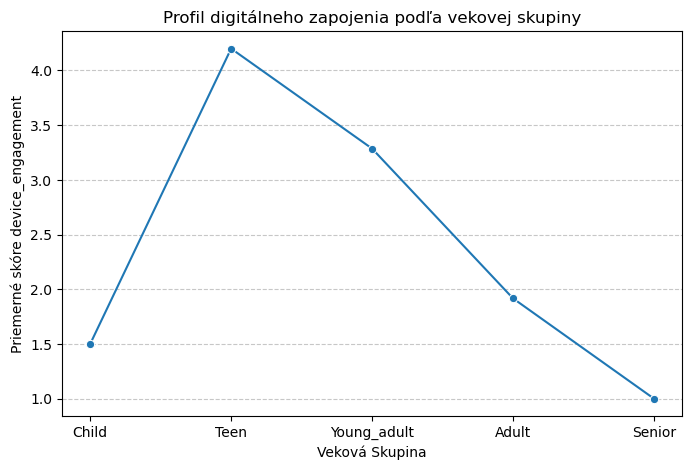

In [42]:
mean_engagement = df.groupby('age_group_num')['device_engagement'].mean().reset_index()

age_labels = {v: k for k, v in age_map.items()}

plt.figure(figsize=(8, 5))
sns.lineplot(data=mean_engagement, x='age_group_num', y='device_engagement', marker='o')
plt.title('Profil digitálneho zapojenia podľa vekovej skupiny')
plt.xlabel('Veková Skupina')
plt.ylabel('Priemerné skóre device_engagement')
plt.xticks(ticks=mean_engagement['age_group_num'], labels=[age_labels[i] for i in mean_engagement['age_group_num']])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

<Figure size 800x500 with 0 Axes>

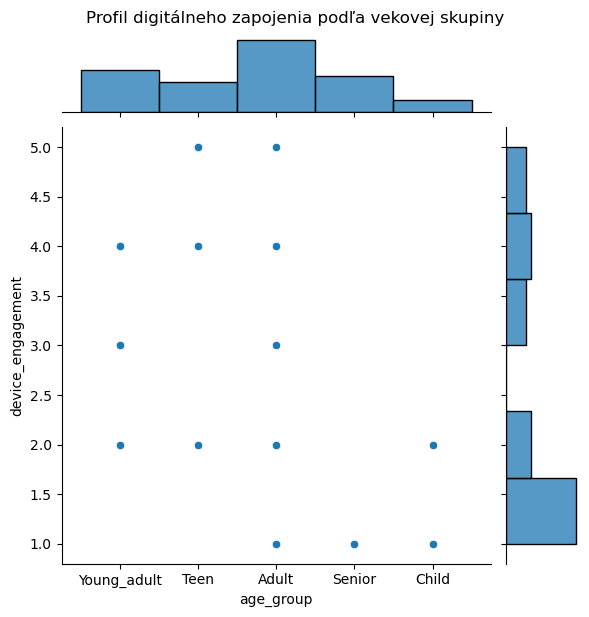

In [43]:
plt.figure(figsize=(8, 5))
sns.jointplot(data=df, x="age_group", y="device_engagement")
plt.suptitle('Profil digitálneho zapojenia podľa vekovej skupiny', y=1.02)
plt.show()

Graf vizuálne potvrdzuje negatívny trend – najvyššiu mieru engagementu vykazujú Teen a Young_adult, zatiaľ čo Seniori takmer nepoužívajú mobil počas jazdy.

**Test 4: `bag_weight_kg` vs. `travelled_distance_km`**

Testujeme, či dlhšie cesty korelujú so zvýšenou potrebou batožiny, ktorá môže byť nutná pre dlhšie dochádzanie alebo cestovanie.

Skorší Shapiro-Wilk test pre `bag_weight_kg` naznačil nenormálne rozdelenie, preto použijeme Spearmanovu koreláciu – neparametrickú alternatívu Pearsonovej korelácie.

H0: Nie je štatisticky významná závislosť medzi premennými bag_weight_kg a travelled_distance_km

In [50]:
corr, p = spearmanr(df['travelled_distance_km'], df['bag_weight_kg'])

print("Spearman rho:", corr)
print("p-hodnota:", p)

Spearman rho: -0.009401124905583196
p-hodnota: 0.9592729491925036


Spearmanov korelačný koeficient dosiahol hodnotu ρ = −0.0094, čo je prakticky nulová korelácia.
P-hodnota testu (p = 0.9593) je výrazne vyššia než hladina významnosti 0.05, takže nulovú hypotézu nezamietame.

<Figure size 800x500 with 0 Axes>

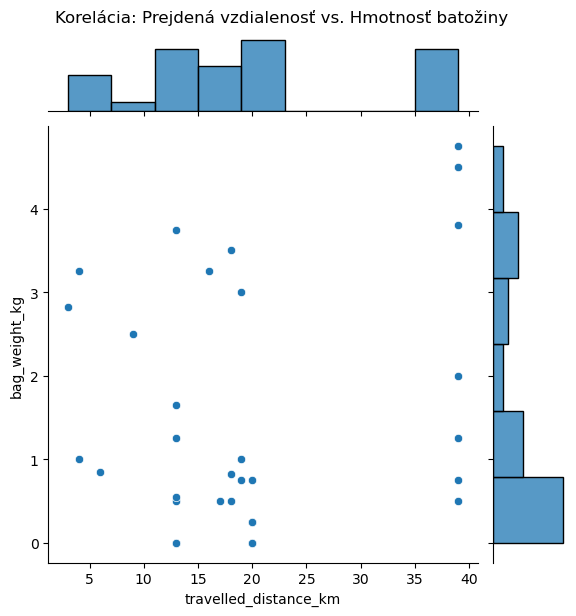

In [45]:
plt.figure(figsize=(8,5))
sns.jointplot(data=df, x="travelled_distance_km", y="bag_weight_kg")
plt.suptitle('Korelácia: Prejdená vzdialenosť vs. Hmotnosť batožiny', y=1.02)
plt.show()

Záver: Neexistuje žiadna štatisticky významná súvislosť medzi dĺžkou cesty (minutes_on_bus) a hmotnosťou batožiny (bag_weight_kg). V praxi to znamená, že cestujúci nenosia systematicky ťažšiu ani ľahšiu batožinu v závislosti od toho, ako dlho cestujú autobusom.

**Test 5: Kontingencia `origin_stop` vs. `is_student`**

Cieľom je zistiť, či nástupná zastávka súvisí s tým, či je cestujúci študent. Obe premenné sú kategorizované (nominálna a binárna), preto je vhodným nástrojom Chi-kvadrát test nezávislosti.

H0: Nie je štatisticky významná závislosť medzi nástupnou zastávkou (`origin_stop`) a statusom cestujúceho (`is_student`).

Vytvoríme kontingenčnú tabuľku, ktorá ukazuje rozloženie študentov a neštudentov na jednotlivých zastávkach:

In [47]:
contingency = pd.crosstab(df['origin_stop'], df['is_student'])
print(contingency)

is_student        False  True 
origin_stop                   
Branč                11      0
Ivanka pri Nitre      1      0
Komjatice             3      5
Nové Zámky            3      4
Veľký Kýr             2      3


Z kontingenčnej tabuľky vidíme výraznú koncentráciu neštudentov na zastávke Branč, kde nebol zaznamenaný ani jeden študent (11 × False, 0 × True). Na ostatných zastávkach síce tiež prevažujú neštudenti, ale zastávky Komjatice, Nové Zámky a Veľký Kýr vykazujú vyšší podiel študentov.

Tieto rozdiely v zastúpení naznačujú možnú súvislosť medzi nástupnou zastávkou a tým, či je cestujúci študent. Preto vykonáme aj formálny Chí-kvadrát test nezávislosti.

In [49]:
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi2:", chi2)
print("p-hodnota:", p)

Chi2: 11.565714285714284
p-hodnota: 0.020890542755210163


Záver: P-hodnota Chí-kvadrát testu je 0.0209, čo je menej ako zvolená hladina významnosti 0.05 - zamietame nulovú hypotézu o nezávislosti. Existuje štatisticky významná závislosť medzi nástupnou zastávkou a statusom študenta.

Výsledky ukazujú, že študenti nie sú rozdelení rovnomerne medzi zastávkami:
- Nové Zámky a Komjatice majú relatívne vysoký podiel študentov,
- Veľký Kýr má tiež zvýšené zastúpenie,
- Branč a Ivanka pri Nitre takmer žiadnych študentov nezachytávajú.

Analýza teda potvrdzuje, že jednotlivé zastávky majú špecifické demografické profily, čo môže byť dôležité pri plánovaní kapacít, trasovaní spojov a cielenej komunikácii dopravcu.

# **Záver**

V tejto analýze sme overili viacero hypotéz týkajúcich sa správania a demografie cestujúcich. Výsledky ukázali, že niektoré vzťahy sú štatisticky významné, zatiaľ čo iné sa nepotvrdili. Kľúčové zistenia, ktoré môžu pomôcť dopravcovi pri rozhodovaní, sú nasledovné:

1. Digitálna Priepasť (test 3): Medzi vekom pasažiera a jeho mierou používania mobilného zariadenia počas jazdy existuje silný a štatisticky významný negatívny vzťah (ρ = −0.6195, p = 0.0002).
To znamená, že mladší cestujúci (Teen, Young_adult) sú výrazne aktívnejší v používaní mobilu. Starší cestujúci (najmä Seniori) vykazujú minimálnu digitálnu aktivitu.

Dopad pre dopravcu:
Digitálne kanály, mobilné aplikácie a online komunikácia budú najúčinnejšie pre mladých cestujúcich. Pre starších treba ponechať "tradičné" formy informovania (hlásenia v autobuse, papierové oznamy).
  
2. Geografické rozdiely medzi zastávkami (test 5): Analýza kontingencie potvrdila, že jednotlivé nástupné zastávky nemajú rovnaké demografické zloženie (p = 0.0456). Niektoré zastávky sú typicky „študentské“, iné sú zasa prevažne pre neštudentov:
- Branč – takmer výlučne neštudenti
- Nové Zámky a Veľký Kýr – vysoký podiel študentov
- Komjatice – zmiešané, ale študentov je výraznejšie

Dopad pre dopravcu:
Umožňuje to cielene plánovať marketing, optimalizovať kapacity alebo upraviť služby podľa typu cestujúcich na jednotlivých zastávkach.


3. Logistické faktory sa nepotvrdili (testy 1, 2 a 4):
- Dĺžka cesty a hmotnosť batožiny spolu vôbec nesúvisia (ρ ≈ 0, p = 0.9593).
- Hmotnosť batožiny u študentov a neštudentov sa štatisticky nelíši (p = 0.4351).
- Nepreukázal sa rozdiel v čase strávenom v autobuse podľa toho, či cestujúci má alebo nemá zľavnený lístok (p = 0.0919).
Logistické vzťahy, ktoré sa v exploračnej analýze javili ako možné, sa nepotvrdili. Zdá sa, že faktory ako batožina či dĺžka cesty sa správajú nezávisle od demografických charakteristík.

  
Analýza by sa mohla rozšíriť o:
1. Porovnanie konkrétnych extrémnych zastávok - Keďže analýza kontingencie ukázala výrazné demografické rozdiely medzi zastávkami (napr. Nové Zámky vs. Branč), bolo by zaujímavé porovnať tieto dve skupiny aj z hľadiska metrických premenných, ako je minutes_on_bus.
Takéto cielené porovnanie by mohlo odhaliť, či sa líši typická dĺžka cesty medzi typicky „študentskými“ a „neštudentskými“ zastávkami. Použiť by sa dal napr. Mann-Whitney U test alebo t-test (podľa splnenia podmienok normality).

1. Regresná analýza - Zatiaľ sme skúmali vzťahy prevažne po dvojiciach premenných, ale regresný model by umožnil určiť, ktoré faktory majú naozaj najväčší vplyv na premenné ako digitálne zapojenie (device_engagement), dĺžka jazdy (minutes_on_bus).
V modeli by sa dali zohľadniť vek, zastávka, zľava, status študenta, či interakcie premenných. To by poskytlo komplexnejší pohľad na správanie cestujúcich.

1. Porovnanie podľa sezóny alebo dňa - Ak by boli dostupné dáta z rôznych období, dalo by sa overiť, či správanie študentov a cestovné návyky sú stabilné v čase.